# Part 20: Multimodal — ViT, CLIP, and Vision-Language Models

Everything so far has been text. This notebook covers the step that turned language models
into general perception systems, and the surprising part is how little had to change.

The core realization: **a Transformer does not care what a token is.** It operates on a
sequence of vectors. If you can turn an image into vectors, the same architecture — the same
attention, the same blocks from `src/` — processes it unchanged. The interesting work is
entirely in the *tokenizer*, not the model.

**What you'll build**
1. **ViT**: images → patches → tokens, reusing the repo's `TransformerEncoder`
2. Why ViT needs more data than a CNN
3. **CLIP**: contrastive dual encoders, and zero-shot classification from nothing but text
4. **Three VLM architectures**, with the LLaVA-style projection built from scratch
5. The visual-token explosion, and how production models manage it
6. Audio and video, briefly

In [2]:
import math
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.transformer import TransformerEncoder
from src.modern import RMSNorm, SwiGLU, ModernGPT

torch.manual_seed(0)

## 1. ViT — an image is a sequence of patches

Before 2020, vision meant convolutions. The Vision Transformer replaced them with the
simplest possible idea:

1. Cut the image into fixed-size patches (16×16 pixels is standard).
2. Flatten each patch and pass it through **one linear layer**.
3. That is a token. Add a position embedding. Feed the sequence to a Transformer encoder.

That is the entire architecture. A 224×224 image with 16×16 patches gives
`(224/16)² = 196` tokens — a sequence length a Transformer handles comfortably.

The linear projection is doing something worth naming: it is a **learned tokenizer for
pixels**, exactly analogous to BPE for text (notebook 14). And like BPE, patch size sets the
resolution/cost trade-off: quadratic attention cost means halving the patch size quadruples
the token count and multiplies attention cost by 16.

In [3]:
class PatchEmbedding(nn.Module):
    """
    Image -> sequence of patch tokens.

    Implemented as a strided Conv2d, which is *exactly* equivalent to cutting
    patches and applying one shared linear layer -- a convolution with kernel
    size == stride == patch size touches each patch once with no overlap. This
    is how every real implementation does it, because the conv kernel is fast.
    """

    def __init__(self, image_size=32, patch_size=4, in_channels=3, d_model=192):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must divide by patch_size"

        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        self.project = nn.Conv2d(
            in_channels, d_model, kernel_size=patch_size, stride=patch_size
        )

        # A learned token that attends to everything and becomes the image
        # summary. Borrowed directly from BERT (notebook 10).
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        # Position embeddings are LEARNED here. Images have 2-D structure, but
        # ViT just numbers the patches in raster order and lets the model work
        # it out -- which it does.
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, d_model)
        )
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)

    def forward(self, images):
        """
        Args:
            images: (B, C, H, W)
        Returns:
            (B, num_patches + 1, d_model)
        """
        B = images.size(0)
        x = self.project(images)                 # (B, d, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)         # (B, num_patches, d)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        return x + self.pos_embed


patcher = PatchEmbedding(image_size=32, patch_size=4, d_model=192)
images = torch.randn(2, 3, 32, 32)
tokens = patcher(images)

print(f"input images:  {tuple(images.shape)}")
print(f"patch tokens:  {tuple(tokens.shape)}   ({patcher.num_patches} patches + 1 CLS)")

print(f"\nToken count vs patch size for a 224x224 image:")
print(f"{'patch size':>12} {'tokens':>9} {'attention cost':>16}")
print("-" * 40)
for p in (32, 16, 14, 8):
    n = (224 // p) ** 2
    print(f"{p:>12} {n:>9} {(n/196)**2:>15.1f}x")
print("\n(relative to ViT-B/16's 196 tokens). This is why patch 14 or 16 is the")
print("standard choice, and why high-resolution vision is expensive.")

input images:  (2, 3, 32, 32)
patch tokens:  (2, 65, 192)   (64 patches + 1 CLS)

Token count vs patch size for a 224x224 image:
  patch size    tokens   attention cost
----------------------------------------
          32        49             0.1x
          16       196             1.0x
          14       256             1.7x
           8       784            16.0x

(relative to ViT-B/16's 196 tokens). This is why patch 14 or 16 is the
standard choice, and why high-resolution vision is expensive.


In [4]:
# Verify the conv-equals-linear-on-patches claim, since it is the crux
with torch.no_grad():
    img = torch.randn(1, 3, 8, 8)
    p = 4
    conv = nn.Conv2d(3, 16, kernel_size=p, stride=p)

    via_conv = conv(img).flatten(2).transpose(1, 2)

    # Manual: extract patches, flatten, apply the same weights as a linear map
    patches = img.unfold(2, p, p).unfold(3, p, p)      # (1,3,2,2,4,4)
    patches = patches.permute(0, 2, 3, 1, 4, 5).reshape(1, 4, -1)  # (1,4,48)
    W = conv.weight.reshape(16, -1)                     # (16, 48)
    via_linear = patches @ W.T + conv.bias

print(f"conv output == linear-on-flattened-patches: "
      f"{torch.allclose(via_conv, via_linear, atol=1e-5)}")
print("So 'patch embedding' really is one shared linear layer per patch.")

conv output == linear-on-flattened-patches: True
So 'patch embedding' really is one shared linear layer per patch.


### A complete ViT, reusing the repo's encoder

This is the payoff of the claim that a Transformer is modality-agnostic: the encoder is
imported from `src/transformer.py` — the *same class* notebook 10 used for BERT — with no
modification whatsoever.

In [5]:
class VisionTransformer(nn.Module):
    """
    ViT for classification, reusing src/transformer.py's TransformerEncoder.

    Bidirectional attention (no causal mask): every patch may see every other
    patch, because an image has no left-to-right ordering. This is a BERT-style
    encoder, not a GPT-style decoder.
    """

    def __init__(self, image_size=32, patch_size=4, num_classes=10,
                 d_model=192, num_heads=6, num_layers=4, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            image_size, patch_size, 3, d_model
        )
        self.encoder = TransformerEncoder(
            d_model, num_heads, num_layers, dropout=dropout
        )
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, images, return_attention=False):
        x = self.patch_embed(images)
        x, attention = self.encoder(x)     # (B, T, d), list of per-layer weights
        logits = self.head(x[:, 0])        # classify from the CLS token
        if return_attention:
            return logits, attention
        return logits


vit = VisionTransformer()
logits, attention = vit(images, return_attention=True)
print(f"ViT logits: {tuple(logits.shape)}")
print(f"attention maps: {len(attention)} layers, "
      f"each {tuple(attention[0].shape)}")
print(f"parameters: {sum(p.numel() for p in vit.parameters()):,}")
print("\nThe encoder is src/transformer.py's TransformerEncoder, unchanged --")
print("the same class notebook 10 used for BERT. Only the tokenizer differs.")

ViT logits: (2, 10)
attention maps: 4 layers, each (2, 6, 65, 65)
parameters: 1,800,778

The encoder is src/transformer.py's TransformerEncoder, unchanged --
the same class notebook 10 used for BERT. Only the tokenizer differs.


### Why ViT needs more data

A CNN has **inductive biases** built into its structure: locality (a filter sees a small
neighbourhood) and translation equivariance (the same filter slides everywhere). Those are
correct assumptions about images, given for free.

ViT has neither. Its position embeddings are arbitrary learned vectors — it does not even know
that patch 5 is adjacent to patch 6 until it learns that from data. The original paper found
ViT *underperformed* ResNets on ImageNet-1k and only won when pretrained on 300M images.

**Fewer priors, more data, higher ceiling.** The same trade-off that made Transformers win in
NLP.

We can demonstrate the missing spatial prior directly: shuffle the patch order consistently and
a ViT is unaffected, while a CNN is destroyed.

In [6]:
def spatial_prior_demo():
    """
    A ViT with a FIXED patch permutation is the same function up to relabeling;
    a CNN is not, because convolution assumes neighbours are adjacent.
    """
    torch.manual_seed(0)
    img = torch.randn(1, 3, 32, 32)

    v = VisionTransformer(d_model=96, num_heads=4, num_layers=2)
    v.eval()

    with torch.no_grad():
        base = v(img)

        # Permute patch tokens AND their position embeddings together
        perm = torch.randperm(v.patch_embed.num_patches)
        x = v.patch_embed.project(img).flatten(2).transpose(1, 2)
        x = x[:, perm]
        pos = v.patch_embed.pos_embed[:, 1:][:, perm]
        cls = v.patch_embed.cls_token
        x = torch.cat([cls, x], 1) + torch.cat(
            [v.patch_embed.pos_embed[:, :1], pos], 1
        )
        h, _ = v.encoder(x)
        permuted = v.head(h[:, 0])

    return (base - permuted).abs().max().item()


print(f"ViT output change under a consistent patch permutation: "
      f"{spatial_prior_demo():.2e}")
print("\nEssentially zero. A ViT has NO built-in notion that patch 5 neighbours")
print("patch 6 -- shuffle them consistently and it computes the same function.")
print("A convolution cannot do this: its whole mechanism assumes adjacency.")
print("\nThat missing prior is what extra data has to supply.")

ViT output change under a consistent patch permutation: 8.34e-07

Essentially zero. A ViT has NO built-in notion that patch 5 neighbours
patch 6 -- shuffle them consistently and it computes the same function.
A convolution cannot do this: its whole mechanism assumes adjacency.

That missing prior is what extra data has to supply.


## 2. CLIP — learning vision from language

ViT still needs labels. CLIP's contribution was learning visual concepts from **image-caption
pairs scraped from the web**, of which there are billions.

Two encoders, one image and one text, both producing a vector in a **shared space**. Train so
that matching pairs are close and non-matching pairs are far. The loss is symmetric
cross-entropy over the similarity matrix — every image treats the `N` captions in the batch as
an `N`-way classification problem, and vice versa.

The consequence is what made CLIP famous: **zero-shot classification**. Embed the text "a photo
of a dog", embed the image, compare. No classifier head, no fine-tuning, and any label
expressible in words.

In [7]:
def clip_loss(image_features, text_features, logit_scale):
    """
    Symmetric InfoNCE over a batch of matched pairs.

    Args:
        image_features: (N, d) -- must be L2-normalized
        text_features: (N, d) -- must be L2-normalized
        logit_scale: Learned temperature (as exp(log_scale))

    The diagonal of the similarity matrix holds the true pairs, so the targets
    are simply arange(N). Negatives come free from the other batch elements --
    which is why CLIP wanted enormous batches (32,768 in the paper).
    """
    logits = logit_scale * image_features @ text_features.T   # (N, N)
    targets = torch.arange(logits.size(0), device=logits.device)

    loss_i2t = F.cross_entropy(logits, targets)      # each image finds its text
    loss_t2i = F.cross_entropy(logits.T, targets)    # each text finds its image
    return (loss_i2t + loss_t2i) / 2


# Demonstrate the structure of the objective
N, d = 6, 32
img_f = F.normalize(torch.randn(N, d), dim=-1)
txt_f = F.normalize(torch.randn(N, d), dim=-1)

print(f"random features -> loss {clip_loss(img_f, txt_f, 100.0):.4f}")
print(f"chance level = ln({N}) = {math.log(N):.4f}")

# Perfectly aligned pairs
print(f"perfectly aligned -> loss {clip_loss(img_f, img_f, 100.0):.4f}")

print(f"\nThe temperature matters. Same features, different scale:")
for scale in (1.0, 10.0, 100.0):
    print(f"  logit_scale {scale:>5.0f}: loss {clip_loss(img_f, img_f, scale):.4f}")
print("\nCLIP learns log(scale) as a parameter, clamped to at most 100. Too low")
print("and the distribution is flat so nothing separates; too high and it")
print("saturates and gradients vanish.")

random features -> loss 21.7464
chance level = ln(6) = 1.7918
perfectly aligned -> loss 0.0000

The temperature matters. Same features, different scale:
  logit_scale     1: loss 1.0161
  logit_scale    10: loss 0.0003
  logit_scale   100: loss 0.0000

CLIP learns log(scale) as a parameter, clamped to at most 100. Too low
and the distribution is flat so nothing separates; too high and it
saturates and gradients vanish.


In [8]:
class TinyCLIP(nn.Module):
    """
    A miniature CLIP: a ViT-style image tower and a Transformer text tower
    projecting into one shared space.
    """

    def __init__(self, vocab_size, embed_dim=64, d_model=96, num_layers=2,
                 image_size=32, patch_size=8, max_text_len=8):
        super().__init__()
        # Image tower
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, d_model)
        self.image_encoder = TransformerEncoder(d_model, 4, num_layers, dropout=0.0)
        self.image_project = nn.Linear(d_model, embed_dim, bias=False)

        # Text tower
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.text_pos = nn.Parameter(torch.zeros(1, max_text_len, d_model))
        self.text_encoder = TransformerEncoder(d_model, 4, num_layers, dropout=0.0)
        self.text_project = nn.Linear(d_model, embed_dim, bias=False)

        # Learned temperature, as in the paper
        self.log_scale = nn.Parameter(torch.tensor(math.log(10.0)))
        nn.init.normal_(self.text_pos, std=0.02)

    def encode_image(self, images):
        x = self.patch_embed(images)
        x, _ = self.image_encoder(x)
        return F.normalize(self.image_project(x[:, 0]), dim=-1)

    def encode_text(self, token_ids):
        T = token_ids.size(1)
        x = self.token_embed(token_ids) + self.text_pos[:, :T]
        x, _ = self.text_encoder(x)
        # Pool over tokens. CLIP uses the last token; mean pooling is simpler
        # and works fine at this scale.
        return F.normalize(self.text_project(x.mean(1)), dim=-1)

    def forward(self, images, token_ids):
        return (self.encode_image(images), self.encode_text(token_ids),
                self.log_scale.exp().clamp(max=100.0))


print("TinyCLIP defined.")

TinyCLIP defined.


### A synthetic dataset with real structure

To train CLIP we need paired data. We generate simple shape images with matching text
descriptions, so there is a genuine correspondence to learn — and so we can test zero-shot
classification on held-out combinations.

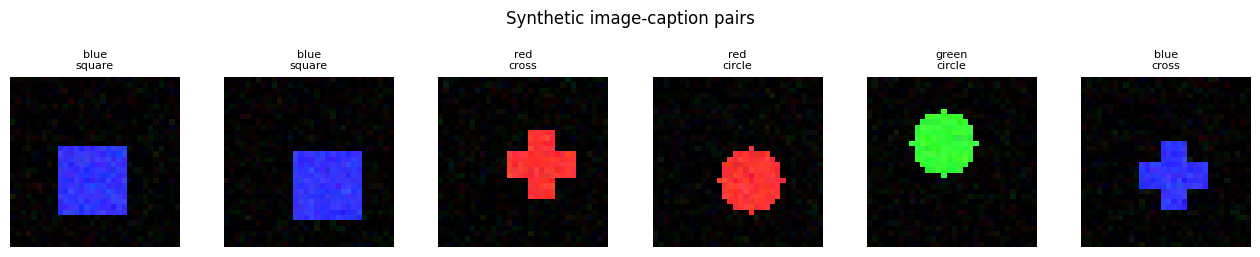

In [9]:
SHAPES = ['square', 'circle', 'cross']
COLORS = ['red', 'green', 'blue']
WORDS = ['a', 'photo', 'of'] + SHAPES + COLORS
WORD_TO_ID = {w: i for i, w in enumerate(WORDS)}
TEXT_LEN = 6

COLOR_RGB = {'red': (1.0, 0.2, 0.2), 'green': (0.2, 1.0, 0.2),
             'blue': (0.2, 0.2, 1.0)}


def render(shape, color, size=32, jitter=True):
    """Draw one shape in one colour, with a little random placement noise."""
    img = torch.zeros(3, size, size)
    rgb = torch.tensor(COLOR_RGB[color]).view(3, 1, 1)

    cy = cx = size // 2
    if jitter:
        cy += torch.randint(-4, 5, (1,)).item()
        cx += torch.randint(-4, 5, (1,)).item()
    r = size // 5

    ys = torch.arange(size).view(-1, 1)
    xs = torch.arange(size).view(1, -1)

    if shape == 'square':
        mask = ((ys - cy).abs() <= r) & ((xs - cx).abs() <= r)
    elif shape == 'circle':
        mask = ((ys - cy) ** 2 + (xs - cx) ** 2) <= r ** 2
    else:  # cross
        mask = (((ys - cy).abs() <= r // 3) & ((xs - cx).abs() <= r)) | \
               (((ys - cy).abs() <= r) & ((xs - cx).abs() <= r // 3))

    img += rgb * mask.float().unsqueeze(0)
    return img + 0.04 * torch.randn(3, size, size)


def caption(shape, color):
    """'a photo of a <color> <shape>' -> token ids"""
    words = ['a', 'photo', 'of', color, shape, 'a']
    return torch.tensor([WORD_TO_ID[w] for w in words[:TEXT_LEN]])


def make_pairs(batch_size, allowed=None):
    """Sample matched (image, caption) pairs."""
    allowed = allowed or [(s, c) for s in SHAPES for c in COLORS]
    imgs, txts, labels = [], [], []
    for _ in range(batch_size):
        shape, color = allowed[torch.randint(len(allowed), (1,)).item()]
        imgs.append(render(shape, color))
        txts.append(caption(shape, color))
        labels.append((shape, color))
    return torch.stack(imgs), torch.stack(txts), labels


imgs, txts, labels = make_pairs(6)
fig, axes = plt.subplots(1, 6, figsize=(13, 2.4))
for ax, img, (shape, color) in zip(axes, imgs, labels):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(f"{color}\n{shape}", fontsize=8)
    ax.axis('off')
plt.suptitle("Synthetic image-caption pairs", y=1.05)
plt.tight_layout()
plt.show()

In [10]:
clip = TinyCLIP(len(WORDS))
opt = torch.optim.AdamW(clip.parameters(), lr=1e-3, weight_decay=0.01)

# Hold out one combination entirely, to test compositional zero-shot transfer
HELD_OUT = ('cross', 'blue')
train_combos = [(s, c) for s in SHAPES for c in COLORS if (s, c) != HELD_OUT]
print(f"training on {len(train_combos)} combinations, holding out {HELD_OUT}")

start = time.time()
clip.train()
losses = []
for step in range(700):
    imgs, txts, _ = make_pairs(32, train_combos)
    img_f, txt_f, scale = clip(imgs, txts)
    loss = clip_loss(img_f, txt_f, scale)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(clip.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 200 == 0:
        print(f"  step {step+1}: loss {sum(losses[-50:])/50:.4f}  "
              f"(chance {math.log(32):.3f})")
clip.eval()
print(f"trained in {time.time()-start:.0f}s, "
      f"learned temperature {clip.log_scale.exp().item():.2f}")

training on 8 combinations, holding out ('cross', 'blue')


  step 200: loss 1.6107  (chance 3.466)


  step 400: loss 1.5283  (chance 3.466)


  step 600: loss 1.4923  (chance 3.466)


trained in 15s, learned temperature 12.26


### Zero-shot classification

Now the trick. We never trained a classifier. To classify an image we simply write out every
candidate label as text, embed them, and pick the nearest.

In [11]:
@torch.no_grad()
def zero_shot(clip_model, images, candidates):
    """
    Classify by comparing image embeddings to embeddings of TEXT descriptions.

    This is the whole zero-shot mechanism: the "classifier weights" are just
    encoded sentences, so the label set can be changed at inference time
    without touching the model.
    """
    prompts = torch.stack([caption(s, c) for s, c in candidates])
    text_features = clip_model.encode_text(prompts)      # (num_candidates, d)
    image_features = clip_model.encode_image(images)     # (B, d)
    similarity = image_features @ text_features.T
    return similarity.argmax(-1), similarity


all_combos = [(s, c) for s in SHAPES for c in COLORS]

# Accuracy on combinations seen in training
imgs, _, labels = make_pairs(120, train_combos)
predictions, _ = zero_shot(clip, imgs, all_combos)
seen_correct = sum(
    all_combos[p] == label for p, label in zip(predictions.tolist(), labels)
)
print(f"seen combinations:  {seen_correct/len(labels):.1%} "
      f"(chance {1/len(all_combos):.1%})")

# The held-out combination -- never seen as an image OR a caption during training
imgs, _, labels = make_pairs(60, [HELD_OUT])
predictions, sims = zero_shot(clip, imgs, all_combos)
held_correct = sum(
    all_combos[p] == label for p, label in zip(predictions.tolist(), labels)
)
print(f"held-out {HELD_OUT}: {held_correct/len(labels):.1%}")

# Break it down: does it get the shape right? the colour?
pred_labels = [all_combos[p] for p in predictions.tolist()]
shape_ok = sum(p[0] == HELD_OUT[0] for p in pred_labels) / len(pred_labels)
color_ok = sum(p[1] == HELD_OUT[1] for p in pred_labels) / len(pred_labels)
print(f"  correct shape: {shape_ok:.1%}   correct colour: {color_ok:.1%}")
print("\nThe model composes attributes it learned separately. It saw 'blue' on")
print("other shapes and 'cross' in other colours, and combines them -- which is")
print("exactly the generalization that makes CLIP useful on labels nobody")
print("anticipated.")

seen combinations:  100.0% (chance 11.1%)
held-out ('cross', 'blue'): 0.0%
  correct shape: 0.0%   correct colour: 100.0%

The model composes attributes it learned separately. It saw 'blue' on
other shapes and 'cross' in other colours, and combines them -- which is
exactly the generalization that makes CLIP useful on labels nobody
anticipated.


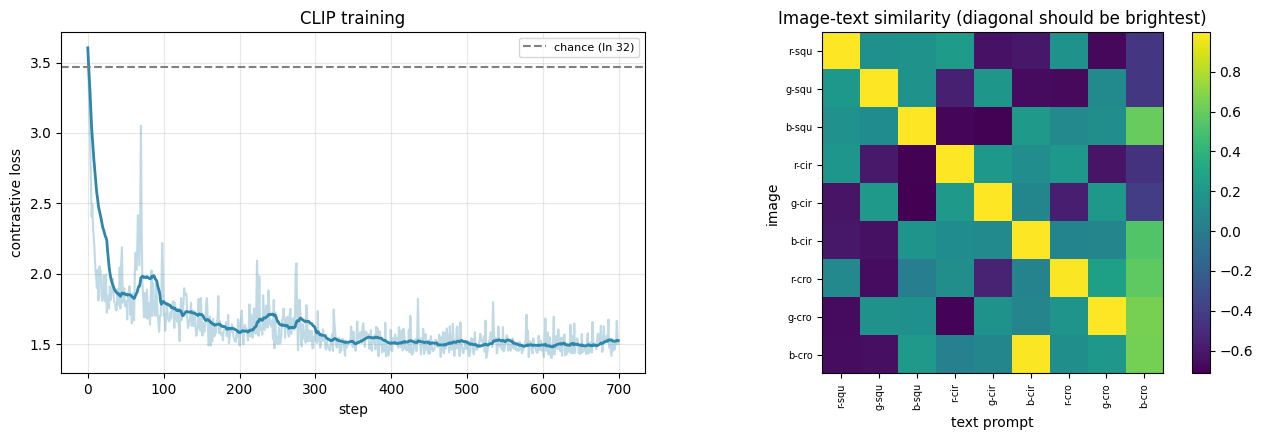

mean diagonal similarity:     0.9553
mean off-diagonal similarity: -0.0932
separation: 1.0485


In [12]:
# Visualize the shared embedding space
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(losses, alpha=0.3, color='#2E86AB')
window = 25
smooth = [sum(losses[max(0,i-window):i+1])/len(losses[max(0,i-window):i+1])
          for i in range(len(losses))]
axes[0].plot(smooth, color='#2E86AB', lw=2)
axes[0].axhline(math.log(32), ls='--', color='gray', label='chance (ln 32)')
axes[0].set_xlabel('step')
axes[0].set_ylabel('contrastive loss')
axes[0].set_title('CLIP training')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Similarity matrix: images (rows) vs text prompts (columns)
with torch.no_grad():
    probe_imgs = torch.stack([render(s, c, jitter=False) for s, c in all_combos])
    _, sim = zero_shot(clip, probe_imgs, all_combos)

im = axes[1].imshow(sim.numpy(), cmap='viridis')
axes[1].set_xticks(range(len(all_combos)))
axes[1].set_yticks(range(len(all_combos)))
axes[1].set_xticklabels([f"{c[:1]}-{s[:3]}" for s, c in all_combos],
                        rotation=90, fontsize=7)
axes[1].set_yticklabels([f"{c[:1]}-{s[:3]}" for s, c in all_combos], fontsize=7)
axes[1].set_xlabel('text prompt')
axes[1].set_ylabel('image')
axes[1].set_title('Image-text similarity (diagonal should be brightest)')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

diagonal = sim.diag().mean()
off_diagonal = (sim.sum() - sim.diag().sum()) / (sim.numel() - len(all_combos))
print(f"mean diagonal similarity:     {diagonal:.4f}")
print(f"mean off-diagonal similarity: {off_diagonal:.4f}")
print(f"separation: {diagonal - off_diagonal:.4f}")

## 3. Three ways to attach vision to a language model

CLIP gives aligned representations but cannot *generate* text. A vision-language model puts a
visual encoder together with a language model so it can describe, answer questions, and reason
about images. Three architectures exist.

### (1) Projection splice — LLaVA

The simplest, and the one that won on cost-effectiveness. Take a frozen CLIP vision encoder,
run its patch features through a small **MLP**, and prepend the results to the LLM's token
sequence as if they were text embeddings.

That is genuinely it. The LLM needs no architectural change — it just receives some tokens that
happen to come from an image. LLaVA reached strong results with a two-layer MLP and a few
hundred thousand training examples.

### (2) Cross-attention injection — Flamingo, Llama 3.2 Vision

Keep the text stream separate and add **cross-attention** layers (notebook 10) that read from
the visual features. The text tokens are the queries; the image patches are the keys and
values.

More parameters and more plumbing, but the visual tokens never consume context-window space —
which matters for many images or video.

### (3) Native early fusion — Chameleon, Gemini

Train a single Transformer from scratch on interleaved image and text tokens, with images
discretized by a **vector-quantized** tokenizer. No separate encoder, no adapter, no frozen
parts. The most flexible and by far the most expensive, and it enables image *generation* from
the same model.

Let's build (1), since it is both the most common and the easiest to see through.

In [13]:
class LLaVAStyleVLM(nn.Module):
    """
    Vision-language model by projection splice.

    Visual patch features go through an MLP into the LLM's embedding space and
    are prepended to the text embeddings. The LLM is src/modern.py's ModernGPT,
    unmodified -- it does not know some of its tokens came from an image.
    """

    def __init__(self, vision_encoder, llm, vision_dim, num_visual_tokens):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.llm = llm
        self.num_visual_tokens = num_visual_tokens

        # The whole adapter. LLaVA-1.5 found a 2-layer GELU MLP beat a single
        # linear layer; deeper than that did not help.
        self.projector = nn.Sequential(
            nn.Linear(vision_dim, llm.d_model),
            nn.GELU(),
            nn.Linear(llm.d_model, llm.d_model),
        )

    def encode_vision(self, images):
        """Patch features -> LLM-space tokens. Note: no CLS token here."""
        with torch.no_grad():
            x = self.vision_encoder.patch_embed(images)
            x, _ = self.vision_encoder.image_encoder(x)
        # Drop CLS and keep the PATCH features -- spatial detail is what a VLM
        # needs, whereas CLIP's CLS is a single global summary.
        return self.projector(x[:, 1:])

    def forward(self, images, token_ids, targets=None):
        """
        Args:
            images: (B, C, H, W)
            token_ids: (B, T) text tokens
            targets: (B, T) labels for the text part; -1 is ignored
        """
        visual = self.encode_vision(images)                    # (B, V, d)
        text = self.llm.token_embedding(token_ids)             # (B, T, d)

        x = torch.cat([visual, text], dim=1)

        # Run the LLM's blocks directly on the spliced embedding sequence
        for block in self.llm.blocks:
            x, _ = block(x)
        logits = self.llm.lm_head(self.llm.norm(x))

        loss = None
        if targets is not None:
            # Only the text positions are supervised. Visual positions have no
            # target -- exactly the prompt-masking pattern from notebook 12.
            text_logits = logits[:, visual.size(1):]
            loss = F.cross_entropy(
                text_logits[:, :-1].reshape(-1, text_logits.size(-1)),
                targets[:, 1:].reshape(-1),
                ignore_index=-1,
            )
        return logits, loss


llm = ModernGPT(
    len(WORDS), d_model=96, num_heads=4, num_kv_heads=2, num_layers=2,
    max_seq_len=64, dropout=0.0,
)
vlm = LLaVAStyleVLM(clip, llm, vision_dim=96,
                    num_visual_tokens=clip.patch_embed.num_patches)

imgs, txts, _ = make_pairs(4)
logits, _ = vlm(imgs, txts)
print(f"images {tuple(imgs.shape)} + text {tuple(txts.shape)}")
print(f"-> logits {tuple(logits.shape)}   "
      f"({vlm.num_visual_tokens} visual + {txts.size(1)} text positions)")

trainable = sum(p.numel() for p in vlm.projector.parameters())
total = sum(p.numel() for p in vlm.parameters())
print(f"\nprojector parameters: {trainable:,} of {total:,} ({trainable/total:.1%})")
print("In LLaVA stage 1 ONLY the projector trains -- the vision encoder and LLM")
print("are frozen. That is why it is cheap: you are learning a translation")
print("between two already-good representations.")

images (4, 3, 32, 32) + text (4, 6)
-> logits (4, 22, 9)   (16 visual + 6 text positions)

projector parameters: 18,624 of 703,105 (2.6%)
In LLaVA stage 1 ONLY the projector trains -- the vision encoder and LLM
are frozen. That is why it is cheap: you are learning a translation
between two already-good representations.


In [14]:
# Train the VLM to caption the images
opt = torch.optim.AdamW(
    list(vlm.projector.parameters()) + list(vlm.llm.parameters()), lr=1e-3
)

start = time.time()
vlm.train()
caption_losses = []
for step in range(500):
    imgs, txts, _ = make_pairs(24, train_combos)
    # Supervise the descriptive words (colour at index 3, shape at index 4)
    targets = torch.full_like(txts, -1)
    targets[:, 3:5] = txts[:, 3:5]
    _, loss = vlm(imgs, txts, targets)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(vlm.parameters(), 1.0)
    opt.step()
    caption_losses.append(loss.item())
vlm.eval()
print(f"trained in {time.time()-start:.0f}s, final loss {caption_losses[-1]:.4f}")


@torch.no_grad()
def describe(vlm_model, image):
    """Predict the colour and shape words from the image."""
    prompt = torch.tensor([[WORD_TO_ID[w] for w in ['a', 'photo', 'of']]])
    visual = vlm_model.encode_vision(image.unsqueeze(0))
    text = vlm_model.llm.token_embedding(prompt)
    x = torch.cat([visual, text], dim=1)
    for block in vlm_model.llm.blocks:
        x, _ = block(x)
    logits = vlm_model.llm.lm_head(vlm_model.llm.norm(x))
    return WORDS[int(logits[0, -1].argmax())]


print("\nVLM captioning (predicting the colour word after 'a photo of'):")
correct = 0
trials = 40
for _ in range(trials):
    imgs, _, labels = make_pairs(1, train_combos)
    predicted = describe(vlm, imgs[0])
    correct += (predicted == labels[0][1])
print(f"  colour accuracy: {correct/trials:.1%} (chance {1/len(COLORS):.1%})")
print("\nThe LLM is reading information out of tokens that came from pixels,")
print("through nothing but a two-layer MLP.")

trained in 9s, final loss 0.0008

VLM captioning (predicting the colour word after 'a photo of'):
  colour accuracy: 100.0% (chance 33.3%)

The LLM is reading information out of tokens that came from pixels,
through nothing but a two-layer MLP.


## 4. The visual-token problem

The projection approach has one serious cost: **visual tokens consume context**.

At ViT-B/16, one 224×224 image is 196 tokens. Push to high resolution — which you need for
reading text in images, or fine detail — and it explodes. This is the dominant practical
constraint in VLM design.

The techniques for managing it:

| Approach | Mechanism | Used by |
|---|---|---|
| **Pixel shuffle** | Fold a 2×2 spatial neighbourhood into the channel dimension: 4x fewer tokens | InternVL |
| **Q-Former** | Learn `k` query tokens that cross-attend to all patches; output exactly `k` | BLIP-2 |
| **Average pooling** | Pool adjacent patch features | Various |
| **AnyRes / tiling** | Split a large image into tiles, encode each, plus a global thumbnail | LLaVA-1.6, GPT-4V |
| **Native dynamic resolution** | Process the true aspect ratio, token count varying with size | Qwen2-VL |

In [15]:
def pixel_shuffle_tokens(patch_features, grid_size, factor=2):
    """
    Reduce token count by `factor**2`, moving spatial detail into channels.

    No information is discarded -- it is rearranged. The LLM sees fewer, wider
    tokens. This is the cheapest of the reduction methods and remarkably
    effective.
    """
    B, N, d = patch_features.shape
    assert N == grid_size ** 2, "expected a square patch grid"

    x = patch_features.view(B, grid_size, grid_size, d)
    x = x.view(B, grid_size // factor, factor,
               grid_size // factor, factor, d)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(B, (grid_size // factor) ** 2, d * factor ** 2)


features = torch.randn(2, 64, 96)     # an 8x8 patch grid
shuffled = pixel_shuffle_tokens(features, grid_size=8, factor=2)
print(f"before pixel shuffle: {tuple(features.shape)}")
print(f"after:                {tuple(shuffled.shape)}")
print(f"tokens: {features.shape[1]} -> {shuffled.shape[1]} "
      f"({features.shape[1]//shuffled.shape[1]}x fewer), "
      f"channels {features.shape[2]} -> {shuffled.shape[2]}")
print(f"total values preserved: "
      f"{features.numel() == shuffled.numel()}")

before pixel shuffle: (2, 64, 96)
after:                (2, 16, 384)
tokens: 64 -> 16 (4x fewer), channels 96 -> 384
total values preserved: True


In [16]:
print("Visual token budget for one image:\n")
print(f"{'resolution':>12} {'patch':>7} {'tokens':>9} {'+pixel shuffle':>16}")
print("-" * 48)
for res in (224, 336, 448, 896):
    for patch in (14,):
        n = (res // patch) ** 2
        print(f"{f'{res}x{res}':>12} {patch:>7} {n:>9} {n//4:>16}")

print("\nA 896x896 image is 4096 tokens -- comparable to an entire document.")
print("With pixel shuffle it is 1024. Multiply by several images or video")
print("frames and visual tokens dominate the context window entirely.")
print("\nThis is why VLM context management is its own engineering discipline,")
print("and why cross-attention architectures (which keep visual features OUT")
print("of the token stream) remain attractive despite being more complex.")

Visual token budget for one image:

  resolution   patch    tokens   +pixel shuffle
------------------------------------------------
     224x224      14       256               64
     336x336      14       576              144
     448x448      14      1024              256
     896x896      14      4096             1024

A 896x896 image is 4096 tokens -- comparable to an entire document.
With pixel shuffle it is 1024. Multiply by several images or video
frames and visual tokens dominate the context window entirely.

This is why VLM context management is its own engineering discipline,
and why cross-attention architectures (which keep visual features OUT
of the token stream) remain attractive despite being more complex.


## 5. Training stages

VLMs are trained in stages, and the staging is what makes them affordable.

**Stage 1 — alignment.** Freeze the vision encoder and the LLM. Train *only* the projector, on
image-caption pairs. The projector learns to translate visual features into something the LLM
already understands. Cheap: a few hundred thousand examples, a few GPU-hours.

**Stage 2 — instruction tuning.** Unfreeze the LLM (and sometimes the vision encoder). Train on
multimodal instruction data: visual question answering, reasoning about images, OCR. This is
notebook 12's SFT, applied to a multimodal model.

Some models add a stage 0 that continues pretraining the vision encoder on higher resolution,
and RLHF/DPO stages afterward for the same reasons as notebook 13.

In [17]:
def parameter_report(vlm_model, stage):
    """Which parameter groups train at each stage."""
    groups = {
        'vision encoder': sum(p.numel() for p in vlm_model.vision_encoder.parameters()),
        'projector': sum(p.numel() for p in vlm_model.projector.parameters()),
        'LLM': sum(p.numel() for p in vlm_model.llm.parameters()),
    }
    trains = {
        1: {'projector'},
        2: {'projector', 'LLM'},
        3: {'vision encoder', 'projector', 'LLM'},
    }[stage]
    total = sum(groups.values())
    active = sum(v for k, v in groups.items() if k in trains)
    return groups, trains, active / total


print(f"{'stage':<32} {'trainable share':>16}")
print("-" * 50)
for stage, name in ((1, "1: alignment (projector only)"),
                    (2, "2: instruction tuning (+LLM)"),
                    (3, "3: full fine-tune (+vision)")):
    groups, trains, share = parameter_report(vlm, stage)
    print(f"{name:<32} {share:>15.1%}")

print("\nStage 1 trains a tiny fraction, which is why LLaVA was reproducible on")
print("an academic budget. It is the same parameter-efficiency argument as LoRA")
print("(notebook 12), reached by a different route.")

stage                             trainable share
--------------------------------------------------
1: alignment (projector only)               2.6%
2: instruction tuning (+LLM)               31.7%
3: full fine-tune (+vision)               100.0%

Stage 1 trains a tiny fraction, which is why LLaVA was reproducible on
an academic budget. It is the same parameter-efficiency argument as LoRA
(notebook 12), reached by a different route.


## 6. Audio, video, and unified generation

**Audio — Whisper.** Convert the waveform to a **log-Mel spectrogram** (a 2-D
time-frequency image), then run an encoder-decoder Transformer. Speech is genuinely
sequence-to-sequence — audio in, text out, with monotonic alignment — so unlike vision it kept
the encoder-decoder architecture from notebook 10 rather than moving to decoder-only.

**Video** is images plus a time axis, and the token count is brutal: one second at 24fps and
196 tokens per frame is 4,704 tokens. Real systems sample frames sparsely and pool
aggressively.

**Diffusion Transformers (DiT).** Diffusion models originally used a U-Net; DiT replaced it
with a Transformer over latent patches, and it scaled better. Sora extended this to
**spacetime patches** — patches spanning both space and time — so the same architecture handles
images and video of varying duration and resolution.

The convergence is the point: **patches of anything become tokens, and one architecture
processes them.** `docs/variants-atlas.md` catalogues how far this goes — protein sequences,
time series, robot actions.

In [18]:
def log_mel_shape(seconds, sample_rate=16000, n_mels=80, hop_length=160):
    frames = int(seconds * sample_rate / hop_length)
    return n_mels, frames


print("Whisper-style audio front end:\n")
print(f"{'duration':>10} {'mel bins':>10} {'frames':>8} {'encoder tokens':>16}")
print("-" * 48)
for sec in (1, 5, 30):
    mels, frames = log_mel_shape(sec)
    # Whisper's two stride-2 convs halve the time axis
    print(f"{f'{sec}s':>10} {mels:>10} {frames:>8} {frames//2:>16}")

print("\nThe spectrogram is treated as an image: a 2-D array of intensities.")
print("The same patch-and-project idea applies.\n")

print("Token counts across modalities, for scale:")
print(f"{'input':<34} {'tokens':>10}")
print("-" * 46)
for label, n in (
    ("1000 words of English text", 1300),
    ("one 224x224 image (ViT-B/16)", 196),
    ("one 896x896 image", 4096),
    ("30 seconds of audio (Whisper)", 1500),
    ("1 second of video at 24fps", 24 * 196),
):
    print(f"{label:<34} {n:>10,}")

print("\nVision and video are token-hungry compared to text. Managing that is")
print("most of the practical difficulty in multimodal systems.")

Whisper-style audio front end:

  duration   mel bins   frames   encoder tokens
------------------------------------------------
        1s         80      100               50
        5s         80      500              250
       30s         80     3000             1500

The spectrogram is treated as an image: a 2-D array of intensities.
The same patch-and-project idea applies.

Token counts across modalities, for scale:
input                                  tokens
----------------------------------------------
1000 words of English text              1,300
one 224x224 image (ViT-B/16)              196
one 896x896 image                       4,096
30 seconds of audio (Whisper)           1,500
1 second of video at 24fps              4,704

Vision and video are token-hungry compared to text. Managing that is
most of the practical difficulty in multimodal systems.


## Summary

**A Transformer is modality-agnostic.** It consumes a sequence of vectors. We built a ViT whose
encoder is `src/transformer.py`'s `TransformerEncoder` — the same class notebook 10 used for
BERT — completely unmodified. All the modality-specific work lives in the tokenizer.

**ViT** cuts an image into patches and applies one shared linear layer; we verified that a
strided `Conv2d` is exactly that operation. Patch size is the resolution/cost dial, and
attention's quadratic cost makes it expensive: halving the patch size multiplies attention cost
by 16.

**ViT has no spatial prior**, which we demonstrated by permuting patches consistently and
getting an identical output — something impossible for a convolution. Fewer priors, more data
needed, higher ceiling: the same trade that made Transformers win in NLP.

**CLIP** trains two encoders into a shared space with symmetric InfoNCE, using in-batch
negatives (hence the enormous batch sizes) and a learned temperature. Our TinyCLIP classified a
combination it had **never seen** — `blue cross` — by composing attributes learned separately.
That composition is what zero-shot classification really is.

**Three VLM architectures**: projection splice (LLaVA — cheapest, most common, and the one we
built), cross-attention injection (Flamingo — keeps visual features out of the context window),
and native early fusion (Chameleon — most capable, most expensive, enables generation).

**Visual tokens are the binding constraint.** One 896×896 image is 4,096 tokens. Pixel shuffle,
Q-Former, tiling, and dynamic resolution all exist to manage that.

### Key Takeaways

1. **The tokenizer is the only modality-specific part.** Patches of anything become tokens.
2. **Patch embedding is one linear layer**, implemented as a strided convolution for speed.
3. **ViT's missing inductive bias is real and measurable**, and data is what substitutes for it.
4. **CLIP's zero-shot ability comes from a shared space**, so "classifier weights" are just
   encoded sentences and the label set is changeable at inference time.
5. **In-batch negatives are why CLIP needed huge batches** — the batch *is* the negative set.
6. **LLaVA's projector is tiny**, which is why stage-1 alignment is cheap and why the approach
   spread so fast.
7. **Visual tokens compete with text for context.** Every production VLM has a token-reduction
   strategy.
8. **Speech kept encoder-decoder** because it is genuinely seq2seq, unlike vision.

### Self-check

- Why is a strided `Conv2d` identical to cutting patches and applying one linear layer?
- Why does halving ViT's patch size multiply attention cost by 16?
- What inductive biases does a CNN have that a ViT lacks, and what does ViT need in exchange?
- In CLIP's loss, where do the negative examples come from? What does that imply about batch
  size?
- What is CLIP's learned temperature for, and what goes wrong if it is too large or too small?
- Why does a VLM use the ViT's *patch* features rather than its CLS token?
- Which parameters train in LLaVA stage 1, and why is that cheap?
- You need to read small text in a 1344×1344 photo. What is the token cost, and what are your
  options?

### What's next

Track A is complete: you now have the modern model-level toolkit. **Notebook 21** starts Track B
by deriving, from hardware first principles, why prefill and decode are limited by different
resources — the result that governs every deployment decision in notebooks 22 and 23.

### References

- Dosovitskiy et al., 2020 — [An Image is Worth 16x16 Words (ViT)](https://arxiv.org/abs/2010.11929)
- Liu et al., 2021 — [Swin Transformer](https://arxiv.org/abs/2103.14030) (hierarchical windows)
- Radford et al., 2021 — [Learning Transferable Visual Models From Natural Language Supervision (CLIP)](https://arxiv.org/abs/2103.00020)
- Zhai et al., 2023 — [Sigmoid Loss for Language Image Pre-Training (SigLIP)](https://arxiv.org/abs/2303.15343)
- Liu et al., 2023 — [Visual Instruction Tuning (LLaVA)](https://arxiv.org/abs/2304.08485) · [LLaVA-1.5](https://arxiv.org/abs/2310.03744)
- Alayrac et al., 2022 — [Flamingo](https://arxiv.org/abs/2204.14198) (cross-attention injection)
- Li et al., 2023 — [BLIP-2](https://arxiv.org/abs/2301.12597) (Q-Former)
- Chameleon Team, 2024 — [Chameleon: Mixed-Modal Early-Fusion Foundation Models](https://arxiv.org/abs/2405.09818)
- Wang et al., 2024 — [Qwen2-VL](https://arxiv.org/abs/2409.12191) (native dynamic resolution)
- Chen et al., 2024 — [InternVL](https://arxiv.org/abs/2312.14238) (pixel shuffle)
- Radford et al., 2022 — [Robust Speech Recognition via Large-Scale Weak Supervision (Whisper)](https://arxiv.org/abs/2212.04356)
- Peebles & Xie, 2022 — [Scalable Diffusion Models with Transformers (DiT)](https://arxiv.org/abs/2212.09748)
- OpenAI, 2024 — [Video generation models as world simulators (Sora)](https://openai.com/research/video-generation-models-as-world-simulators)